# EDA - 대학생 중도탈락(Dropout) 예측
데이터: UCI Predict Students' Dropout and Academic Success    
목표: 모델링 전, 데이터 구조와 이탈(Dropout)에 영향을 주는 요인을 시각적으로 파악한다.

## 0. 라이브러리 & 데이터 로드

In [3]:
import platform
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# OS별 폰트 자동 감지
if platform.system() == 'Windows':
    font_name = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    font_name = 'AppleGothic'
else:
    font_name = 'NanumBarunGothic'

# 그래프 스타일 설정
sns.set_theme(style='whitegrid', rc={'font.family': font_name, 'axes.unicode_minus': False})

# 그래프 이미지 저장
FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [4]:
# 데이터 로드 및 기본 전처리
df = pd.read_csv("../data/raw/data.csv", sep=';', encoding='utf-8-sig')
df.columns = [c.strip() for c in df.columns]
df['target_binary'] = (df['Target'] == 'Dropout').astype(int)

print(df.shape)
df.head()

(4424, 38)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,target_binary
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,0


---

## 1. 데이터 개요

In [5]:
print("행 x 열:", df.shape)
print("결측치 총합:", df.isnull().sum().sum())
print("중복행:", df.duplicated().sum())

df.describe().T[['mean','std','min','max']].head(10)

행 x 열: (4424, 38)
결측치 총합: 0
중복행: 0


,mean,std,min,max
Marital status,1.178571,0.605747,1.0,6.0
Application mode,18.669078,17.484682,1.0,57.0
Application order,1.727848,1.313793,0.0,9.0
Course,8856.642631,2063.566416,33.0,9991.0
Daytime/evening attendance,0.890823,0.311897,0.0,1.0
Previous qualification,4.577758,10.216592,1.0,43.0
Previous qualification (grade),132.613314,13.188332,95.0,190.0
Nacionality,1.873192,6.914514,1.0,109.0
Mother's qualification,19.561935,15.603186,1.0,44.0
Father's qualification,22.275316,15.343108,1.0,44.0


#### **확인 결과**
* 4,424행 x 37열(+파생 target_binary), 결측치 0개, 중복행 0개로 매우 깨끗한 데이터입니다.
---

## 2. Target 분포

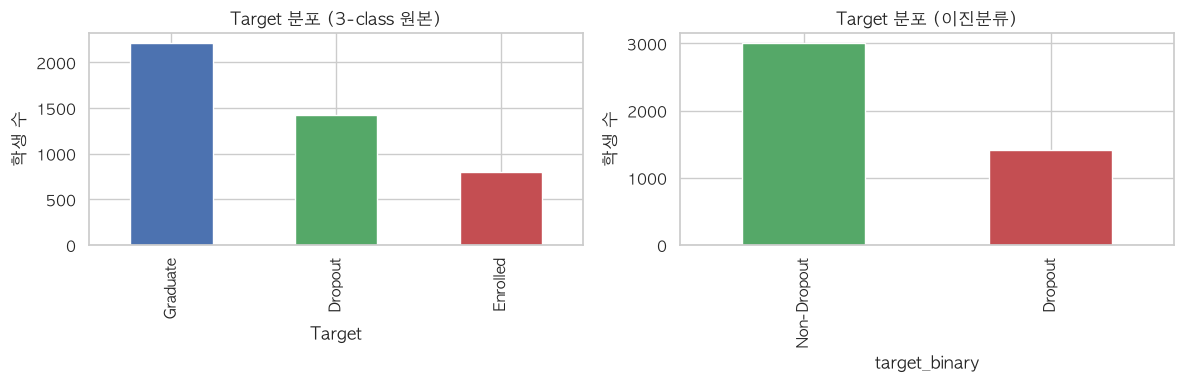

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
target_binary
0    0.6788
1    0.3212
Name: proportion, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Target'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#55A868','#C44E52'])
axes[0].set_title('Target 분포 (3-class 원본)')
axes[0].set_ylabel('학생 수')

df['target_binary'].map({0:'Non-Dropout', 1:'Dropout'}).value_counts().plot(
    kind='bar', ax=axes[1], color=['#55A868','#C44E52'])
axes[1].set_title('Target 분포 (이진분류)')
axes[1].set_ylabel('학생 수')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/target_distribution.png", dpi=120)
plt.show()

print(df['Target'].value_counts())
print(df['target_binary'].value_counts(normalize=True).round(4))


#### **해석**
* Graduate 49.9% / Dropout 32.1% / Enrolled 18.0%.    
* 이진분류 기준으로는 Non-Dropout 67.9% : Dropout 32.1% (약 2:1)로, 심한 불균형은 아니지만 모델 학습 시 고려는 필요한 수준이다.
---

## 3. 주요 연속형 변수 분포 (Target별 비교)

/var/folders/qz/hyvszw9n4ms9wd1s5wn7fm2c0000gn/T/ipykernel_33567/222727267.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_binary', y=col, ax=ax, palette=['#55A868','#C44E52'])
/var/folders/qz/hyvszw9n4ms9wd1s5wn7fm2c0000gn/T/ipykernel_33567/222727267.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Non-Dropout', 'Dropout'])
/var/folders/qz/hyvszw9n4ms9wd1s5wn7fm2c0000gn/T/ipykernel_33567/222727267.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_binary', y=col, ax=ax, palette=['#55A868','#C44E52'])
/var

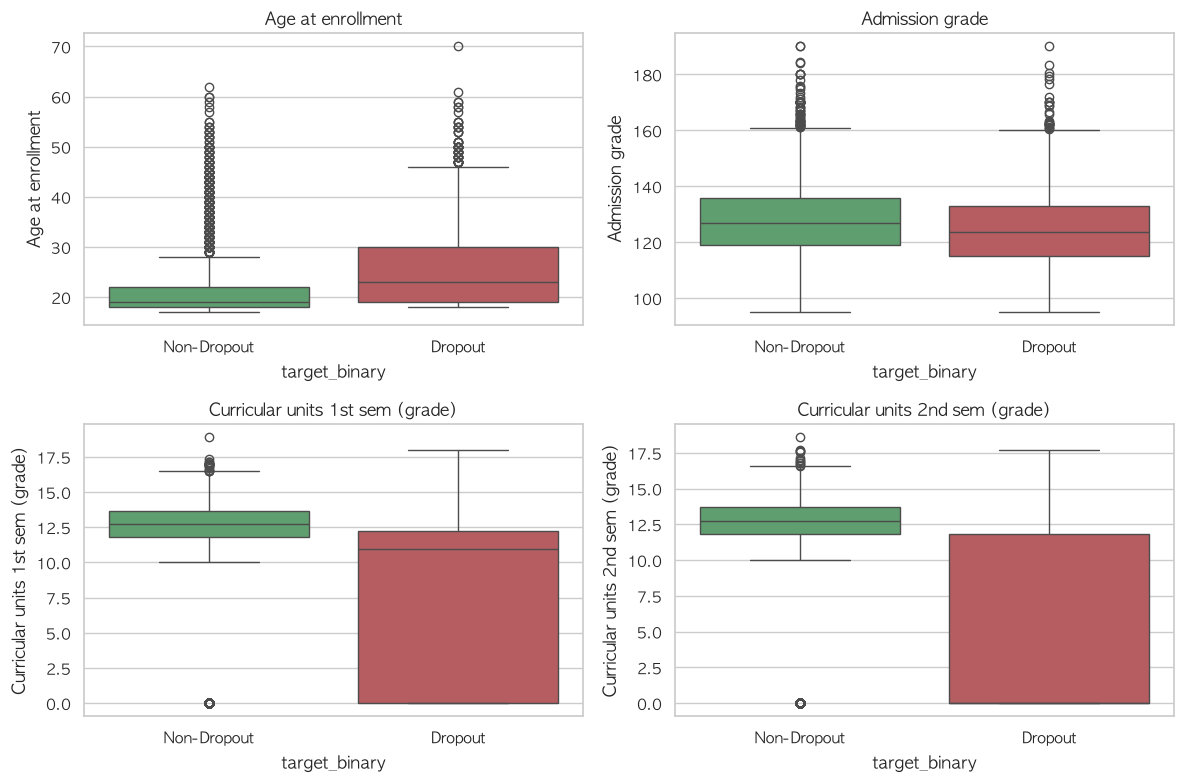

In [ ]:
num_features = ['Age at enrollment', 'Admission grade',
                'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_features):
    sns.boxplot(data=df, x='target_binary', y=col, ax=ax, palette=['#55A868','#C44E52'])
    ax.set_xticklabels(['Non-Dropout', 'Dropout'])
    ax.set_title(col)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/numeric_boxplots.png", dpi=120)
plt.show()


#### **해석**
* 1·2학기 평점 모두 Dropout 그룹에서 중앙값이 뚜렷하게 낮고, 특히 2학기 평점 0점(과목을 아예 이수하지 못한 경우)에 몰려있는 학생 다수가 Dropout 그룹에 속한다.    
* 입학 성적(Admission grade)은 두 그룹 간 차이가 상대적으로 작다.
---

## 4. 범주형/이진 변수별 이탈률 비교

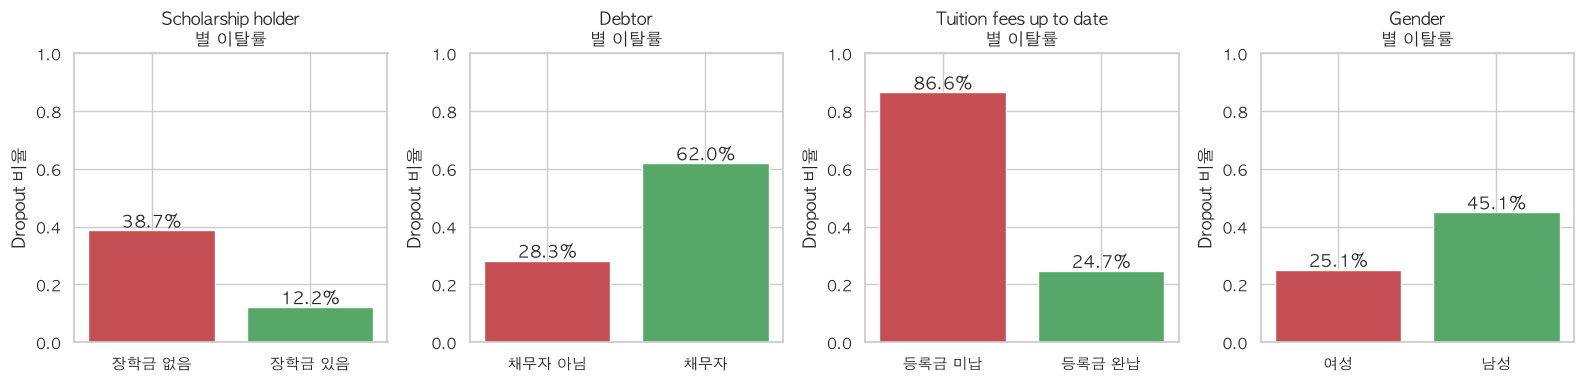


[Scholarship holder]
Scholarship holder
0    0.387
1    0.122
Name: target_binary, dtype: float64

[Debtor]
Debtor
0    0.283
1    0.620
Name: target_binary, dtype: float64

[Tuition fees up to date]
Tuition fees up to date
0    0.866
1    0.247
Name: target_binary, dtype: float64

[Gender]
Gender
0    0.251
1    0.451
Name: target_binary, dtype: float64


In [8]:
cat_features = ['Scholarship holder', 'Debtor', 'Tuition fees up to date', 'Gender']
labels = {'Scholarship holder': ['장학금 없음','장학금 있음'],
          'Debtor': ['채무자 아님','채무자'],
          'Tuition fees up to date': ['등록금 미납','등록금 완납'],
          'Gender': ['여성','남성']}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cat_features):
    rate = df.groupby(col)['target_binary'].mean()
    ax.bar(labels[col], rate.values, color=['#C44E52','#55A868'])
    ax.set_title(f'{col}\n별 이탈률')
    ax.set_ylabel('Dropout 비율')
    ax.set_ylim(0, 1.0)
    for i, v in enumerate(rate.values):
        ax.text(i, v+0.01, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/categorical_dropout_rate.png", dpi=120)
plt.show()

for col in cat_features:
    print(f"\n[{col}]")
    print(df.groupby(col)['target_binary'].mean().round(3))


#### **해석**
* 장학금 미보유(38.7%) vs 보유(12.2%), 채무자(62.0%) vs 비채무자(28.3%)
* 특히 "등록금 미납 그룹의 이탈률은 86.6%"로 완납 그룹(24.7%)의 3배가 넘는다
    * 재정 상태가 이탈을 가장 직접적으로 가르는 요인 중 하나임을 확인.
* 성별 간에도 차이가 있다(그룹1: 45.1% vs 그룹0: 25.1%, 약 20%p 차이)
    * 다만 Gender 코드의 정확한 성별 매핑은 공식 변수표로 재확인 권장.
---

## 5. 상관관계 히트맵 (주요 수치형 변수 vs Target)

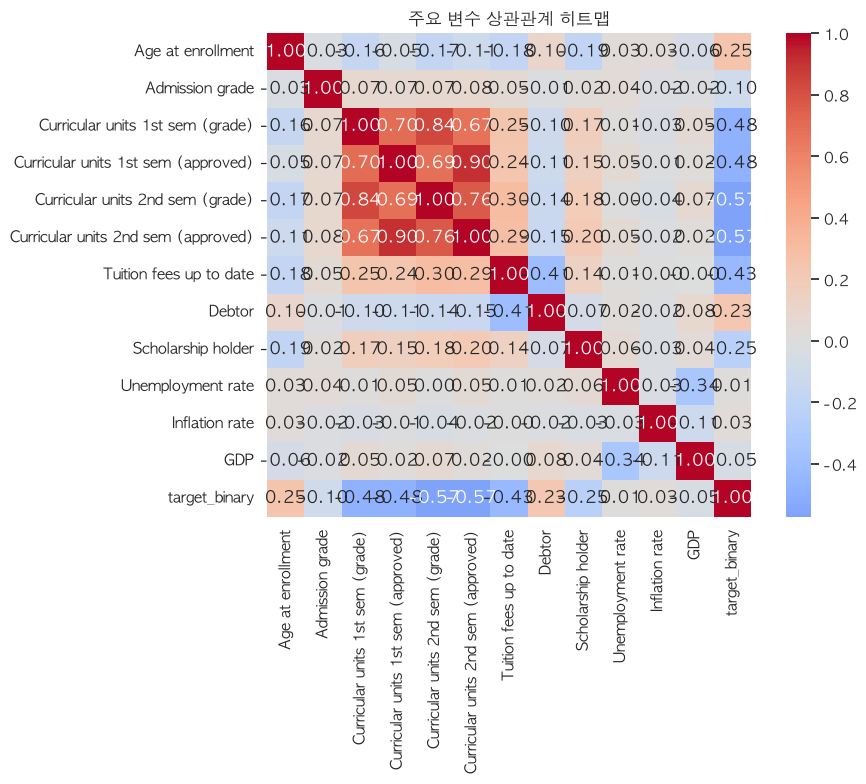

target_binary                          1.000000
Curricular units 2nd sem (grade)      -0.571792
Curricular units 2nd sem (approved)   -0.569500
Curricular units 1st sem (grade)      -0.480669
Curricular units 1st sem (approved)   -0.479112
Tuition fees up to date               -0.429149
Age at enrollment                      0.254215
Scholarship holder                    -0.245354
Debtor                                 0.229407
Admission grade                       -0.095806
GDP                                   -0.046319
Inflation rate                         0.027826
Unemployment rate                      0.012980
Name: target_binary, dtype: float64


In [9]:
corr_features = ['Age at enrollment', 'Admission grade',
                  'Curricular units 1st sem (grade)', 'Curricular units 1st sem (approved)',
                  'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (approved)',
                  'Tuition fees up to date', 'Debtor', 'Scholarship holder',
                  'Unemployment rate', 'Inflation rate', 'GDP', 'target_binary']

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('주요 변수 상관관계 히트맵')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png", dpi=120)
plt.show()

print(corr_matrix['target_binary'].sort_values(key=lambda x: x.abs(), ascending=False))

#### **해석**
* target_binary와 가장 강하게 연관된 변수는 2학기 이수과목 수/평점(-0.57 내외)이며, 등록금 완납 여부(-0.43)가 뒤를 잇는다.
* 거시경제 지표(실업률/물가/GDP)는 개별 학생 단위 이탈과는 상관이 거의 없다.
---

## 6. 파생변수 미리보기: 학기별 승인율 & 재정 위험 점수

/var/folders/qz/hyvszw9n4ms9wd1s5wn7fm2c0000gn/T/ipykernel_33567/3377487311.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_binary', y='sem1_approval_rate', ax=axes[0], palette=['#55A868','#C44E52'])
/var/folders/qz/hyvszw9n4ms9wd1s5wn7fm2c0000gn/T/ipykernel_33567/3377487311.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Non-Dropout', 'Dropout']); axes[0].set_title('1학기 승인율')
/var/folders/qz/hyvszw9n4ms9wd1s5wn7fm2c0000gn/T/ipykernel_33567/3377487311.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ta

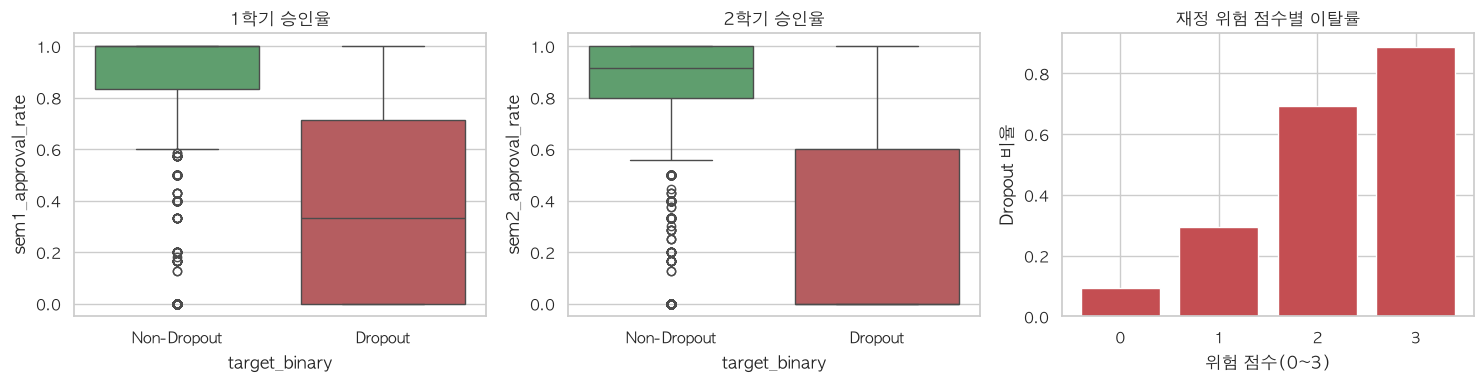

승인율/재정위험점수 vs target_binary 상관계수
sem1_approval_rate     -0.591236
sem2_approval_rate     -0.659413
financial_risk_score    0.435261
target_binary           1.000000
Name: target_binary, dtype: float64

재정 위험 점수별 이탈률:
financial_risk_score
0    0.093
1    0.293
2    0.692
3    0.888
Name: target_binary, dtype: float64


In [10]:
df['sem1_approval_rate'] = np.where(df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'], 0)
df['sem2_approval_rate'] = np.where(df['Curricular units 2nd sem (enrolled)'] > 0,
    df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (enrolled)'], 0)
df['financial_risk_score'] = (
    (df['Tuition fees up to date'] == 0).astype(int) +
    (df['Debtor'] == 1).astype(int) +
    (df['Scholarship holder'] == 0).astype(int)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='target_binary', y='sem1_approval_rate', ax=axes[0], palette=['#55A868','#C44E52'])
axes[0].set_xticklabels(['Non-Dropout', 'Dropout']); axes[0].set_title('1학기 승인율')

sns.boxplot(data=df, x='target_binary', y='sem2_approval_rate', ax=axes[1], palette=['#55A868','#C44E52'])
axes[1].set_xticklabels(['Non-Dropout', 'Dropout']); axes[1].set_title('2학기 승인율')

risk_rate = df.groupby('financial_risk_score')['target_binary'].mean()
axes[2].bar(risk_rate.index.astype(str), risk_rate.values, color='#C44E52')
axes[2].set_title('재정 위험 점수별 이탈률'); axes[2].set_xlabel('위험 점수(0~3)'); axes[2].set_ylabel('Dropout 비율')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/derived_features.png", dpi=120)
plt.show()

print("승인율/재정위험점수 vs target_binary 상관계수")
print(df[['sem1_approval_rate','sem2_approval_rate','financial_risk_score','target_binary']].corr()['target_binary'])
print()
print("재정 위험 점수별 이탈률:")
print(risk_rate.round(3))


#### **해석**
* 승인율은 낮을수록(특히 2학기, 상관계수 -0.66) 이탈률이 급격히 높아지는 명확한 패턴을 보인다. 
* 재정 위험 점수는 더욱 극적이다
    * **위험요인 0개: 이탈률 9.3% → 1개: 29.3% → 2개: 69.2% → 3개(모두 해당): 88.8%**로 거의 선형에 가까운 계단식 증가를 보임.
* 두 변수 모두 전처리 단계에서 파생변수로 채택할 근거가 충분하다.
---

## 7. 이상치·특이 케이스: 학기 시작 직후 미등록 학생

In [11]:
df['zero_enrolled_1st_sem'] = (df['Curricular units 1st sem (enrolled)'] == 0).astype(int)
zero_ratio = df.groupby('zero_enrolled_1st_sem')['target_binary'].mean()

print("1학기 등록과목 0명 학생 수:", df['zero_enrolled_1st_sem'].sum(),
      f"({df['zero_enrolled_1st_sem'].mean():.1%})")
print("\n등록 여부별 이탈률:")
print(zero_ratio.round(3))

1학기 등록과목 0명 학생 수: 180 (4.1%)

등록 여부별 이탈률:
zero_enrolled_1st_sem
0    0.317
1    0.428
Name: target_binary, dtype: float64


#### **해석**
* 1학기 등록과목이 0개인 학생은 전체의 약 4.1%(180명)로 소수이며, 이탈률 차이(약 5.4% vs 3.4%)는 존재하지만 크지 않다. 
* 표본이 적어 상관계수 자체는 약하게 나타나지만(뒤 전처리 결과서 참고), 트리 기반 모델에서는 여전히 유의미한 분기 기준이 될 수 있어 파생 플래그로 유지한다.
---

## 8. Marital Status 분포 (참고)

In [12]:
print(df['Marital status'].value_counts())
print(df['Marital status'].value_counts(normalize=True).round(3))

Marital status
1    3919
2     379
4      91
5      25
6       6
3       4
Name: count, dtype: int64
Marital status
1    0.886
2    0.086
4    0.021
5    0.006
6    0.001
3    0.001
Name: proportion, dtype: float64


#### **해석**
* 88.6%가 코드 1(미혼 추정)에 쏠려있어, 이 컬럼 단독으로는 변별력이 낮을 수 있다. 
* 원-핫 인코딩 시 나머지 카테고리들이 자연스럽게 저빈도로 처리된다.

---
## 인사이트 요약

1. **가장 강력한 이탈 신호는 학업 성취도**
    * 학기별 이수/승인 과목 수, 평점, 특히 승인율(합격/등록 비율)이 이탈과 가장 강하게 연관된다 
    * (상관계수 -0.57 ~ -0.66 수준, 2학기 승인율이 단일 변수 중 최강).
2. **재정 상태가 가장 극적인 신호**
    * 등록금 미납 그룹 이탈률 86.6% vs 완납 그룹 24.7% (3배 이상 차이). 
    * 재정 위험 요인 개수(0~3개)에 따라 이탈률이 9.3% → 29.3% → 69.2% → 88.8%로 거의 선형적으로 증가.
3. **거시경제 지표는 개인 단위 예측에 거의 도움이 안 됨**
    * 실업률/물가/GDP는 개별 학생의 이탈 여부와 상관관계가 거의 없다 — 지역·시기별 집계 효과이지 개인 특성이 아니기 때문으로 추정
4. **소수 특이 케이스(학기 미등록)도 유지할 가치 있음**
    * 1학기 미등록 학생(180명, 4.1%)의 이탈률은 42.8%로 일반 학생(31.7%)보다 11%p 높다. 
    * 표본이 적어 단순 상관계수로는 약하게(0.047) 나타나지만, 실제 이탈률 차이는 뚜렷해 트리 기반 모델에서 유의미한 분기 신호로 활용 가능
5. **모델링 시 참고**
    * 학업성취도 계열, 재정상태 계열 피처를 핵심 축으로 사용하고, class_weight 또는 threshold 튜닝으로 32:68 불균형에 대응 필요.

전처리 단계(`notebooks/preprocess.ipynb`)에서는 위 인사이트를 반영해 승인율, 재정위험점수, 성적변화량, 학기미등록 플래그를 파생변수로 이미 생성해두었다.